# IMPORTATION DES BIBLIOTHÈQUES 

In [4]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [7]:
# Donnees du dataset clientele
revenu = np.array ([20 , 25 , 30 , 35 , 40 , 45 , 50 , 55 , 60 , 65])
depense = np.array ([150 , 200 , 250 , 280 , 350 , 370 , 420 , 480 , 510 , 550])

# Creer un DataFrame pour un affichage propre
df = pd.DataFrame ({'Revenu ( keuros )': revenu ,'Depense ( euros )': depense })
print ( df )
print (f"\nMoyenne revenu : { revenu.mean()}")
print (f"Moyenne depense : { depense.mean()}")

   Revenu ( keuros )  Depense ( euros )
0                 20                150
1                 25                200
2                 30                250
3                 35                280
4                 40                350
5                 45                370
6                 50                420
7                 55                480
8                 60                510
9                 65                550

Moyenne revenu : 42.5
Moyenne depense : 356.0


# Entraînement du modèle

In [13]:
 # Sklearn attend X en 2D : ( n_samples , n_features )
X = revenu.reshape ( -1 , 1)
y = depense

# Creer et entrainer le modele
model = LinearRegression ()
model.fit(X , y )

# Afficher les coefficients
beta_1 = model.coef_ [0]
beta_0 = model.intercept_
print (f" beta_0 ( intercept ) = { beta_0 :.2f}")
print (f" beta_1 ( pente ) = { beta_1 :.3f}")
print (f"\nModele : y_hat = { beta_0 :.2f} + { beta_1 :.3f} * x")

 beta_0 ( intercept ) = -23.15
 beta_1 ( pente ) = 8.921

Modele : y_hat = -23.15 + 8.921 * x


# Visualisation de droite de regression

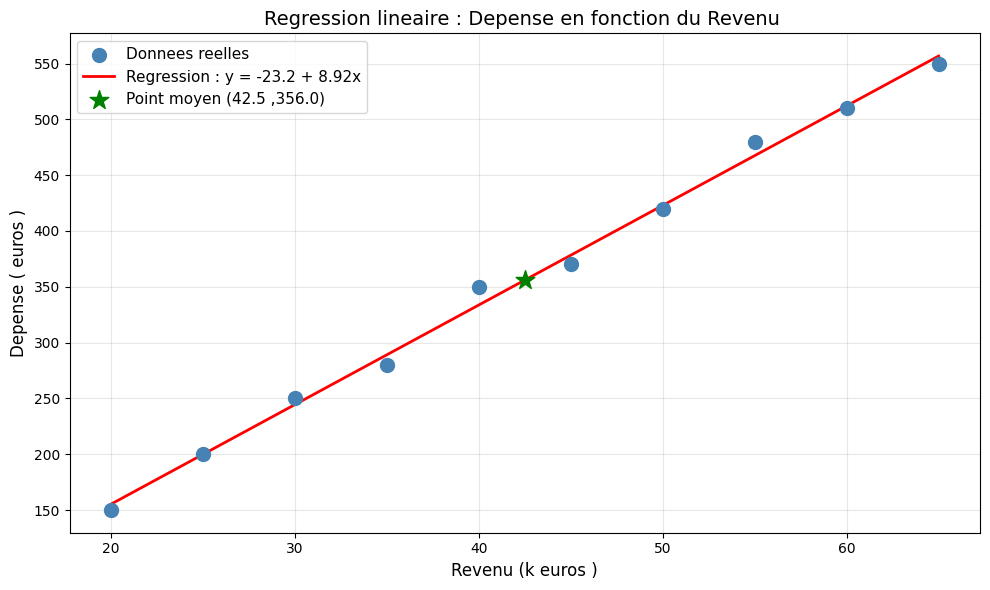

In [15]:
# Predictions
y_pred = model.predict(X)

# Graphique
plt.figure( figsize =(10 , 6) )
plt.scatter ( revenu , depense , color ='steelblue', s =100 ,label ='Donnees reelles', zorder =5)
plt.plot ( revenu , y_pred , color ='red', linewidth =2 ,label =f'Regression : y = { beta_0 :.1f} + { beta_1 :.2f}x')

# Point moyen
plt.scatter( revenu.mean() , depense.mean() , color ='green',s =200 , marker ='*', zorder =6 , label = f'Point moyen ({ revenu.mean()} ,{ depense.mean() }) ')

plt.xlabel('Revenu (k euros )', fontsize =12)
plt.ylabel('Depense ( euros )', fontsize =12)
plt.title('Regression lineaire : Depense en fonction du Revenu ',fontsize =14)
plt.legend( fontsize =11)
plt.grid(True , alpha =0.3)
plt.tight_layout()
plt.show()

# Visualiser les résidus

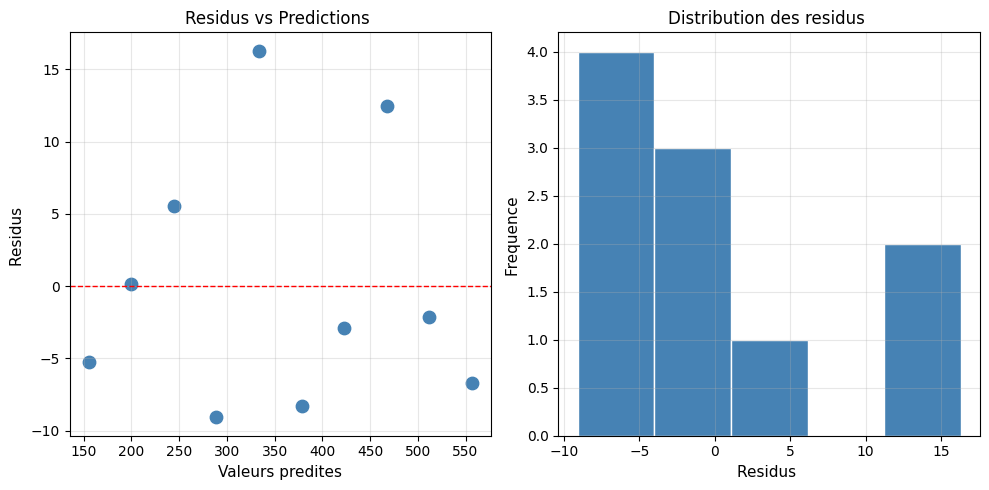

Moyenne des residus : 0.0000
La moyenne des residus est proche de 0 : OK !


In [17]:
residus = depense - y_pred

plt.figure ( figsize =(10 , 5) )

# Graphique 1 : residus vs valeurs predites
plt.subplot(1 , 2, 1)
plt.scatter( y_pred , residus , color ='steelblue', s =80)
plt.axhline(y =0 , color ='red', linestyle ='--', linewidth =1)
plt.xlabel ('Valeurs predites', fontsize =11)
plt.ylabel ('Residus ', fontsize =11)
plt.title ('Residus vs Predictions ', fontsize =12)
plt.grid (True , alpha =0.3)

# Graphique 2 : histogramme des residus
plt.subplot (1 , 2, 2)
plt.hist( residus , bins =5 , color ='steelblue', edgecolor ='white')
plt.xlabel('Residus ', fontsize =11)
plt.ylabel('Frequence ', fontsize =11)
plt.title('Distribution des residus ', fontsize =12)
plt.grid(True , alpha =0.3)
plt.tight_layout()
plt.show()

print (f"Moyenne des residus : { residus.mean() :.4f}")
print (f"La moyenne des residus est proche de 0 : OK !")

# Calcul de $R^{2}$

In [20]:

r2 = r2_score( depense , y_pred )
print(f"R2 = {r2 :.4f}")
print(f"Le modele explique {r2 *100:.1f}% de la variabilite .")

# Erreur quadratique moyenne ( MSE et RMSE )
mse = mean_squared_error ( depense , y_pred )
rmse = np . sqrt ( mse )
print (f"\nMSE = {mse :.2f}")
print (f"RMSE = { rmse :.2f} euros ")
print (f"En moyenne , le modele se trompe de { rmse :.1f} euros .")

R2 = 0.9958
Le modele explique 99.6% de la variabilite .

MSE = 68.97
RMSE = 8.30 euros 
En moyenne , le modele se trompe de 8.3 euros .


# Faire des prédictions 

In [22]:
nouveaux_revenus = np.array ([28 , 48 , 72]).reshape ( -1 , 1)
predictions = model . predict ( nouveaux_revenus )

print (" Predictions pour de nouveaux clients :")
print ("-" * 40)
for rev , pred in zip( nouveaux_revenus.flatten() , predictions ) :
    print (f" Revenu = {rev} k euros -> Depense predite = { pred :.1f} euros ")

 Predictions pour de nouveaux clients :
----------------------------------------
 Revenu = 28 k euros -> Depense predite = 226.6 euros 
 Revenu = 48 k euros -> Depense predite = 405.1 euros 
 Revenu = 72 k euros -> Depense predite = 619.2 euros 


# Vérification à la main

In [24]:
# Verification : calculer beta_1 et beta_0 manuellement
x_bar = revenu.mean()
y_bar = depense.mean()

# Numerateur : sum (( xi - x_bar ) * (yi - y_bar ))
numerateur = np.sum (( revenu - x_bar ) * ( depense - y_bar ))

# Denominateur : sum (( xi - x_bar )^2)
denominateur = np.sum (( revenu - x_bar ) **2)

beta_1_manuel = numerateur / denominateur
beta_0_manuel = y_bar - beta_1_manuel * x_bar

print (f" Calcul manuel :")
print (f" beta_1 = { beta_1_manuel :.4f}")
print (f" beta_0 = { beta_0_manuel :.4f}")
print (f"\nScikit - learn :")
print (f" beta_1 = { model.coef_ [0]:.4f}")
print (f" beta_0 = { model.intercept_ :.4f}")
print (f"\nLes resultats sont identiques !")

 Calcul manuel :
 beta_1 = 8.9212
 beta_0 = -23.1515

Scikit - learn :
 beta_1 = 8.9212
 beta_0 = -23.1515

Les resultats sont identiques !
